# Parte 5 — Galeria de falhas

**O que o enunciado pede.** Cinco imagens em que o modelo final erra feio, cada
uma com a figura (imagem, ground truth, predição e o mapa intermediário
relevante — para a Trilha A, as três classes fundo/interior/fronteira e o mapa
de distância) e um **diagnóstico** quantitativo. Obrigatório: calcular o **campo
receptivo teórico do encoder** (slides 35–38) e compará-lo com a **distribuição
de tamanhos dos objetos** do dataset; se houver *atrous convolution*, mostrar o
campo receptivo com e sem ela para a mesma resolução de saída. E fazer **uma
correção**: escolher um diagnóstico, implementar a mudança que ele sugere e
mostrar o antes/depois.

**Modelo final.** O checkpoint da Parte 4 (`results/4_trilha_a_unet.pt`):
Trilha A sobre a U-Net (fundo / interior / fronteira + distância, decodificada
por watershed), focal balanceada γ=2, treinada a 128×128 com o split das Partes
1, 2 e 4 (`SEED=67`). Se o checkpoint não existir, a célula de modelo treina do
zero com a mesma configuração.

## Roteiro

1. **Campo receptivo teórico** — fórmula recursiva dos slides
   (`r_out = r_in + (k_eff − 1)·j_in`, `j_out = j_in·s`), camada a camada, para
   a U-Net (encoder até o gargalo e rede inteira até a saída), conferida por
   autograd; e para a DeepLabV3 da Parte 3 **com e sem** a convolução dilatada,
   na mesma resolução de saída.
2. **Tamanhos dos objetos** — diâmetro equivalente de todos os 29 461 núcleos
   do dataset, em resolução nativa e na resolução de treino, contra o campo
   receptivo.
3. **Galeria** — as cinco piores imagens de validação (F1@0,50 por imagem),
   com os erros classificados em *perdido / fundido / partido / mal delimitado /
   falso positivo*, a figura de seis painéis e o diagnóstico.
4. **Correção** — a mudança que o diagnóstico dominante sugere, com controle e
   antes/depois nas mesmas imagens e no conjunto de validação inteiro.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import sys
import os

sys.path.append(os.path.abspath(".."))

import json
import copy
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, random_split
from scipy import ndimage
from PIL import Image

from src.dataset.bbbc038 import BBBC038Dataset, SegmentationTransform

from src.nn.models import TrilhaAModel, UNet, SegNet, DeepLabV3
from src.nn.optimizers import create_optimizer

from src.nn.loss import focal_loss, l1_loss

from src.nn.targets import instance_map_to_boundary_targets, decode_watershed

from src.nn.metrics import (
    binary_iou_dice,
    label_map_iou_matrix,
    label_map_overlap_matrix,
    instance_scores_from_map,
    greedy_match_from_iou,
    count_tp_fp_fn_from_iou,
    mean_average_precision_from_iou,
)

from src.nn.tiling import compact_labels

In [2]:
# ============================================================
# CONFIGURACOES
# ============================================================

SEED = 67                      # mesmo split das Partes 1, 2 e 4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_ROOT = "../data/stage1_train"

# ------------------------------------------------------------
# Modelo final (o da Parte 4)
# ------------------------------------------------------------

TRAIN_SIZE      = 128
BACKBONE        = "unet"
MIN_INST_PIXELS = 4
LOSS_CFG        = dict(kind="focal", gamma=2.0, balanced=True)
DISTANCE_WEIGHT = 1.0
NUM_EPOCHS      = 10
BATCH_SIZE      = 16
INTERIOR_THRESH = 0.50

# Espessura da fronteira (treino) e tamanho minimo de marcador (decodificacao)
# por resolucao. A 256 os dois sao dobrados/quadruplicados para manter o
# mesmo teto de decodificador (~88-89% dos nucleos do GT com marcador, ver
# 4_inference.ipynb) -- assim a correcao isola a RESOLUCAO como variavel.
DECODE = {
    128: dict(boundary_width=1, min_marker_size=2),
    256: dict(boundary_width=2, min_marker_size=4),
}

# ------------------------------------------------------------
# Galeria e correcao
# ------------------------------------------------------------

N_GALLERY   = 5
MIN_GT      = 5                # so imagens com >= 5 nucleos entram na galeria
CORRECTION_SIZE = 256          # resolucao da correcao
FT_EPOCHS   = 3                # epocas de fine-tuning (controle @128 e correcao @256)
FT_LR       = 5e-4

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

CHECKPOINT       = os.path.join(RESULTS_DIR, "4_trilha_a_unet.pt")
CHECKPOINT_FT128 = os.path.join(RESULTS_DIR, "5_trilha_a_unet_ft128.pt")
CHECKPOINT_FT256 = os.path.join(RESULTS_DIR, "5_trilha_a_unet_ft256.pt")
SIZES_CSV        = os.path.join(RESULTS_DIR, "5_object_sizes.csv")

CLASS_NAMES = ["fundo", "interior", "fronteira"]

ERROR_COLORS = {
    "ok":             (0.35, 0.35, 0.35),
    "perdido":        (1.00, 0.15, 0.15),
    "fundido":        (1.00, 0.55, 0.00),
    "partido":        (1.00, 1.00, 0.20),
    "mal delimitado": (0.70, 0.30, 0.90),
    "falso positivo": (0.20, 0.50, 1.00),
}

Device: cpu


## Alvos, treino, decodificação e dados (os mesmos das Partes 2–4)

In [3]:
def build_targets(instance_map_batch, boundary_width):
    sem, dist = [], []
    for i in range(instance_map_batch.shape[0]):
        s, d = instance_map_to_boundary_targets(
            instance_map_batch[i].detach().cpu().numpy(),
            boundary_width=boundary_width,
            min_pixels=MIN_INST_PIXELS,
        )
        sem.append(s)
        dist.append(d)
    return torch.stack(sem), torch.stack(dist)


def semantic_loss_fn(pred, target):
    return focal_loss(pred, target, class_weights="balanced", gamma=LOSS_CFG["gamma"])


def train_epoch(dataloader, model, optimizer, boundary_width):

    model.train()
    acc = {"loss": 0.0, "semantic": 0.0, "distance": 0.0}

    for X, instance_map in dataloader:

        X = X.to(device)
        sem_t, dist_t = build_targets(instance_map, boundary_width)
        sem_t, dist_t = sem_t.to(device), dist_t.to(device)

        sem_logits, dist_logits = model(X)
        dist_pred = torch.sigmoid(dist_logits).squeeze(1)

        sem_loss  = semantic_loss_fn(sem_logits, sem_t)
        dist_loss = l1_loss(dist_pred, dist_t)
        loss = sem_loss + DISTANCE_WEIGHT * dist_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        acc["loss"] += loss.item(); acc["semantic"] += sem_loss.item(); acc["distance"] += dist_loss.item()

    n = len(dataloader)
    return {k: v / n for k, v in acc.items()}


def watershed_from_outputs(sem_prob, dist_pred, min_marker_size):
    interior_mask   = sem_prob[1] > INTERIOR_THRESH
    foreground_mask = sem_prob.argmax(axis=0) != 0
    return decode_watershed(
        interior_mask=interior_mask,
        foreground_mask=foreground_mask,
        landscape=-dist_pred,
        min_marker_size=min_marker_size,
    )


@torch.no_grad()
def forward_np(model, batch):
    model.eval()
    sem_logits, dist_logits = model(batch.to(device))
    return (
        torch.softmax(sem_logits, dim=1).cpu().numpy(),
        torch.sigmoid(dist_logits).squeeze(1).cpu().numpy(),
    )


# ------------------------------------------------------------
# Dados: o split e o mesmo para qualquer resolucao (mesma seed, mesmo n)
# ------------------------------------------------------------

def make_split(size, augment):
    transform = SegmentationTransform(size=(size, size), augment=augment)
    dataset = BBBC038Dataset(root=DATA_ROOT, transform=transform, mode="instance")
    n_total = len(dataset)
    n_train = int(0.8 * n_total)
    n_val = n_total - n_train
    train_split, val_split = random_split(
        dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED)
    )
    return dataset, train_split, val_split


base_dataset, _, val_split_128 = make_split(TRAIN_SIZE, augment=False)
print(f"validacao: {len(val_split_128)} imagens")

validacao: 134 imagens


## Modelo final (checkpoint da Parte 4)

In [4]:
def load_or_train(checkpoint, size, epochs, init_state=None, lr=1e-3, tag=""):
    '''
    Carrega `checkpoint` se existir; senao treina `epochs` epocas na
    resolucao `size` (a partir de `init_state`, se dado) e salva.
    '''
    model = TrilhaAModel(BACKBONE).to(device)

    if os.path.exists(checkpoint):
        ckpt = torch.load(checkpoint, map_location=device)
        model.load_state_dict(ckpt["state_dict"])
        print(f"[{tag}] checkpoint carregado: {checkpoint}  (config: {json.dumps(ckpt.get('config', {}))})")
        model.eval()
        return model, ckpt.get("history", [])

    if init_state is not None:
        model.load_state_dict(init_state)

    _, train_split, _ = make_split(size, augment=True)
    loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    optimizer = create_optimizer("Adam", model, lr=lr)
    bw = DECODE[size]["boundary_width"]

    history = []
    t0 = time.time()
    for epoch in range(epochs):
        logs = train_epoch(loader, model, optimizer, bw)
        history.append(logs)
        print(f"[{tag}] epoca {epoch + 1:2d}/{epochs} | loss {logs['loss']:.4f} | "
              f"semantic {logs['semantic']:.4f} | distance {logs['distance']:.4f} | {(time.time() - t0) / 60:.1f} min")

    config = {"backbone": BACKBONE, "loss": LOSS_CFG, "boundary_width": bw, "image_size": [size, size],
              "epochs": epochs, "lr": lr, "from": None if init_state is None else CHECKPOINT,
              "min_marker_size": DECODE[size]["min_marker_size"], "split_seed": SEED}
    torch.save({"state_dict": model.state_dict(), "history": history, "config": config}, checkpoint)
    print(f"[{tag}] checkpoint salvo em {checkpoint}")
    model.eval()
    return model, history


model, history = load_or_train(CHECKPOINT, TRAIN_SIZE, NUM_EPOCHS, tag="modelo final @128")

[modelo final @128] checkpoint carregado: results\4_trilha_a_unet.pt  (config: {"backbone": "unet", "loss": {"kind": "focal", "gamma": 2.0, "balanced": true}, "boundary_width": 1, "min_inst_pixels": 4, "distance_weight": 1.0, "epochs": 10, "batch_size": 16, "image_size": [128, 128], "split_seed": 67, "interior_thresh": 0.5, "min_marker_size": 2})


## 1. Campo receptivo teórico do encoder (slides 35–38)

Os slides mostram que um filtro 3×3 vê 3×3, um 5×5 vê 5×5, e que **pooling**
aumenta o campo receptivo sem acrescentar parâmetros, ao custo de resolução
(slide 38). A forma recursiva disso, camada a camada, é:

$$r_{\text{out}} = r_{\text{in}} + (k_{\text{eff}} - 1)\, j_{\text{in}}, \qquad
  j_{\text{out}} = j_{\text{in}} \cdot s, \qquad
  k_{\text{eff}} = d\,(k - 1) + 1$$

onde `r` é o campo receptivo (em pixels da entrada), `j` o *jump* (distância,
na entrada, entre dois pixels vizinhos do mapa), `k` o kernel, `s` o stride e
`d` a dilatação. Uma convolução transposta 2×2 com stride 2 não aumenta `r`
(cada saída depende de exatamente uma entrada) e divide `j` por 2.

O **encoder** da U-Net (`ConvBlock` = duas 3×3, três max-pools 2×2) chega ao
gargalo com *output stride* 8; o decoder continua ampliando o campo receptivo
até a saída. A conta abaixo é conferida **empiricamente** por autograd:
gradiente de um pixel central da saída em relação à entrada (ReLU trocada por
identidade e entrada aleatória, para nenhum caminho ser zerado por acaso). A
fórmula é um limite superior: o valor exato depende do alinhamento do pixel com
as grades de pooling.

Para a **DeepLabV3** da Parte 3 (`enc3` com `dilation=2` no lugar do segundo
pool, output stride 2), o campo receptivo é calculado **com e sem** a dilatação,
na **mesma** resolução de saída — é o que o enunciado pede a quem usou *atrous*.

In [5]:
# ============================================================
# CAMPO RECEPTIVO  --  formula recursiva, camada a camada
# ============================================================

def receptive_field(layers):
    '''layers: lista de (nome, k, s, d). Devolve linhas (nome, k, s, d, jump, r).'''
    r, j = 1, 1
    rows = []
    for name, k, s, d in layers:
        k_eff = d * (k - 1) + 1
        r = r + (k_eff - 1) * j
        j = j * s
        rows.append({"camada": name, "k": k, "s": s, "d": d, "jump": j, "RF": int(r)})
    return rows


CONV = lambda name, d=1: (name, 3, 1, d)
POOL = lambda name: (name, 2, 2, 1)
UP   = lambda name: (name, 1, 0.5, 1)      # ConvTranspose2d(2, stride 2): r fixo, jump / 2

unet_encoder = [CONV("enc1.conv1"), CONV("enc1.conv2"), POOL("pool1"),
                CONV("enc2.conv1"), CONV("enc2.conv2"), POOL("pool2"),
                CONV("enc3.conv1"), CONV("enc3.conv2"), POOL("pool3")]
unet_decoder = [UP("up3"), CONV("dec3.conv1"), CONV("dec3.conv2"),
                UP("up2"), CONV("dec2.conv1"), CONV("dec2.conv2"),
                UP("up1"), CONV("dec1.conv1"), CONV("dec1.conv2")]

unet_rows = receptive_field(unet_encoder + unet_decoder)
RF_ENCODER = unet_rows[len(unet_encoder) - 1]["RF"]
RF_OUTPUT  = unet_rows[-1]["RF"]

print(f"U-Net: campo receptivo do ENCODER (gargalo, output stride 8) = {RF_ENCODER} px | "
      f"da SAIDA (apos o decoder) = {RF_OUTPUT} px")
pd.DataFrame(unet_rows)

U-Net: campo receptivo do ENCODER (gargalo, output stride 8) = 36 px | da SAIDA (apos o decoder) = 64 px


,camada,k,s,d,jump,RF
0,enc1.conv1,3,1.0,1,1.0,3
1,enc1.conv2,3,1.0,1,1.0,5
2,pool1,2,2.0,1,2.0,6
3,enc2.conv1,3,1.0,1,2.0,10
4,enc2.conv2,3,1.0,1,2.0,14
5,pool2,2,2.0,1,4.0,16
6,enc3.conv1,3,1.0,1,4.0,24
7,enc3.conv2,3,1.0,1,4.0,32
8,pool3,2,2.0,1,8.0,36
9,up3,1,0.5,1,4.0,36


In [6]:
# ============================================================
# DEEPLAB: com e sem atrous, MESMA resolucao de saida (output stride 2)
# ============================================================

def deeplab_layers(dilation):
    enc = [CONV("enc1.conv1"), CONV("enc1.conv2"), POOL("pool"),
           CONV("enc2.conv1"), CONV("enc2.conv2"),
           CONV(f"enc3.conv1 (d={dilation})", dilation), CONV(f"enc3.conv2 (d={dilation})", dilation)]
    aspp = [("aspp 3x3 d=18 (maior ramo)", 3, 1, 18)]
    return enc, aspp

rf_table = []
for label, dil in [("DeepLabV3 com atrous (enc3 d=2)", 2), ("DeepLabV3 sem atrous (enc3 d=1)", 1)]:
    enc, aspp = deeplab_layers(dil)
    rows_enc = receptive_field(enc)
    rows_all = receptive_field(enc + aspp)
    rf_table.append({"modelo": label, "output stride": rows_enc[-1]["jump"],
                     "RF encoder (antes da ASPP)": rows_enc[-1]["RF"], "RF apos ASPP": rows_all[-1]["RF"]})

rf_table.append({"modelo": "U-Net (3 pools)", "output stride": 8,
                 "RF encoder (antes da ASPP)": RF_ENCODER, "RF apos ASPP": np.nan})

seg_rows = receptive_field(unet_encoder + [UP("up3"), CONV("dec3.conv1"), CONV("dec3.conv2"),
                                           UP("up2"), CONV("dec2.conv1"), CONV("dec2.conv2"),
                                           UP("up1"), CONV("dec1.conv1"), CONV("dec1.conv2")])
print("Mesma resolucao de saida (stride 2): a dilatacao amplia o campo receptivo do encoder sem\n"
      "nenhum pool extra; a U-Net precisa de 3 pools (stride 8) para chegar perto disso.\n")
pd.DataFrame(rf_table).set_index("modelo")

Mesma resolucao de saida (stride 2): a dilatacao amplia o campo receptivo do encoder sem
nenhum pool extra; a U-Net precisa de 3 pools (stride 8) para chegar perto disso.



,output stride,RF encoder (antes da ASPP),RF apos ASPP
modelo,,,
DeepLabV3 com atrous (enc3 d=2),2,30,102.0
DeepLabV3 sem atrous (enc3 d=1),2,22,94.0
U-Net (3 pools),8,36,NaN


In [7]:
# ============================================================
# CONFERENCIA EMPIRICA (autograd)
# ============================================================

def empirical_rf(module_fn, size=256, seed=0):
    '''Extensao (altura, largura) da regiao da entrada com gradiente != 0 para um pixel central da saida.'''
    torch.manual_seed(seed)
    x = torch.randn(1, 3, size, size, requires_grad=True)
    out = module_fn(x)
    cy, cx = out.shape[-2] // 2, out.shape[-1] // 2
    out[0, :, cy, cx].sum().backward()
    g = (x.grad[0].abs().sum(0) > 0).numpy()
    ys, xs = np.nonzero(g)
    return int(ys.max() - ys.min() + 1), int(xs.max() - xs.min() + 1)


def linearized(module):
    # ReLU -> identidade: nenhum caminho de gradiente e zerado por acaso
    m = copy.deepcopy(module).eval()
    for _, sub in list(m.named_modules()):
        for attr, child in list(sub.named_children()):
            if isinstance(child, nn.ReLU):
                setattr(sub, attr, nn.Identity())
    return m


u = linearized(UNet(num_classes=2))
unet_bottleneck = lambda x: u.pool(u.enc3(u.pool(u.enc2(u.pool(u.enc1(x))))))

d2 = linearized(DeepLabV3(num_classes=2))
d1 = linearized(DeepLabV3(num_classes=2))
for conv in d1.enc3.block:                     # mesma rede, sem dilatacao
    if isinstance(conv, nn.Conv2d):
        conv.dilation, conv.padding = (1, 1), (1, 1)

checks = {
    f"U-Net encoder (formula {RF_ENCODER})":          empirical_rf(unet_bottleneck),
    f"U-Net saida (formula {RF_OUTPUT}, limite sup.)": empirical_rf(u.forward_features),
    "DeepLab encoder com atrous (formula 30)":        empirical_rf(lambda x: d2.enc3(d2.enc2(d2.pool(d2.enc1(x))))),
    "DeepLab encoder sem atrous (formula 22)":        empirical_rf(lambda x: d1.enc3(d1.enc2(d1.pool(d1.enc1(x))))),
    "DeepLab saida com atrous (formula 102 + upsample)": empirical_rf(d2.forward_features),
    "DeepLab saida sem atrous (formula 94 + upsample)":  empirical_rf(d1.forward_features),
}
for k, v in checks.items():
    print(f"{k:52s}: empirico {v[0]} x {v[1]} px")

U-Net encoder (formula 36)                          : empirico 36 x 36 px
U-Net saida (formula 64, limite sup.)               : empirico 60 x 60 px
DeepLab encoder com atrous (formula 30)             : empirico 30 x 30 px
DeepLab encoder sem atrous (formula 22)             : empirico 22 x 22 px
DeepLab saida com atrous (formula 102 + upsample)   : empirico 104 x 104 px
DeepLab saida sem atrous (formula 94 + upsample)    : empirico 96 x 96 px


## 2. Distribuição de tamanhos dos objetos vs. campo receptivo

Diâmetro equivalente ($2\sqrt{A/\pi}$) de **todas** as máscaras do
`stage1_train`, em resolução nativa e reescalado para a resolução de treino
(128×128: o fator é $\sqrt{128^2/(H\,W)}$, porque o resize não preserva a
proporção). O resultado é cacheado em `results/5_object_sizes.csv`.

                 mediana   p90   p99    max
nativo              19.7  34.8  59.6  118.5
@128 (treino)        6.0  12.0  21.6   41.8
@256 (correcao)     12.0  24.1  43.2   83.5

nucleos com diametro > RF do encoder (36 px):  nativo 9.2% | @128 0.0% | @256 3.2%
nucleos com diametro > RF da saida (64 px):    nativo 0.5% | @128 0.0% | @256 0.0%
nucleos com diametro < 5 px:                    nativo 0.0% | @128 31.1% | @256 8.4%
nucleos com diametro < 3 px:                    nativo 0.0% | @128 12.6% | @256 3.6%

resolucoes nativas: [(256, 256), (256, 320), (260, 347), (360, 360), (512, 640), (520, 696), (603, 1272), (1024, 1024), (1040, 1388)]


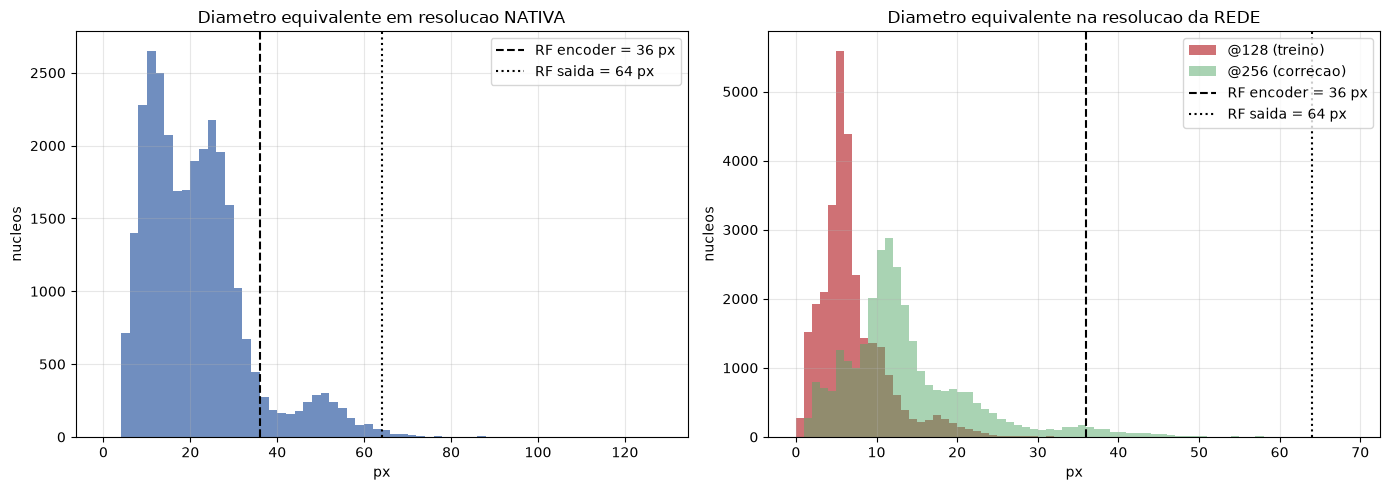

In [8]:
if os.path.exists(SIZES_CSV):
    sizes = pd.read_csv(SIZES_CSV)
else:
    t0 = time.time()
    rows = []
    for i, s in enumerate(base_dataset.samples):
        with Image.open(s["image"]) as im:
            W, H = im.size
        for mask_path in s["masks"]:
            area = int((np.asarray(Image.open(mask_path).convert("L")) > 0).sum())
            rows.append({"image": i, "H": H, "W": W, "area": area})
    sizes = pd.DataFrame(rows)
    sizes.to_csv(SIZES_CSV, index=False)
    print(f"{len(sizes)} mascaras de {len(base_dataset.samples)} imagens em {time.time() - t0:.0f}s")

sizes = sizes[sizes.area > 0].copy()
sizes["d_nativo"] = 2 * np.sqrt(sizes.area / np.pi)
sizes["escala_128"] = np.sqrt(TRAIN_SIZE ** 2 / (sizes.H * sizes.W))
sizes["d_128"] = sizes.d_nativo * sizes.escala_128
sizes["d_256"] = sizes.d_128 * (CORRECTION_SIZE / TRAIN_SIZE)

def describe(d):
    return {"mediana": np.median(d), "p90": np.percentile(d, 90), "p99": np.percentile(d, 99), "max": d.max()}

size_stats = pd.DataFrame({
    "nativo": describe(sizes.d_nativo), "@128 (treino)": describe(sizes.d_128), "@256 (correcao)": describe(sizes.d_256),
}).T
print(size_stats.round(1))

print(f"\nnucleos com diametro > RF do encoder ({RF_ENCODER} px):  nativo {100 * (sizes.d_nativo > RF_ENCODER).mean():.1f}% | "
      f"@128 {100 * (sizes.d_128 > RF_ENCODER).mean():.1f}% | @256 {100 * (sizes.d_256 > RF_ENCODER).mean():.1f}%")
print(f"nucleos com diametro > RF da saida ({RF_OUTPUT} px):    nativo {100 * (sizes.d_nativo > RF_OUTPUT).mean():.1f}% | "
      f"@128 {100 * (sizes.d_128 > RF_OUTPUT).mean():.1f}% | @256 {100 * (sizes.d_256 > RF_OUTPUT).mean():.1f}%")
print(f"nucleos com diametro < 5 px:                    nativo {100 * (sizes.d_nativo < 5).mean():.1f}% | "
      f"@128 {100 * (sizes.d_128 < 5).mean():.1f}% | @256 {100 * (sizes.d_256 < 5).mean():.1f}%")
print(f"nucleos com diametro < 3 px:                    nativo {100 * (sizes.d_nativo < 3).mean():.1f}% | "
      f"@128 {100 * (sizes.d_128 < 3).mean():.1f}% | @256 {100 * (sizes.d_256 < 3).mean():.1f}%")
print("\nresolucoes nativas:", sorted(set(zip(sizes.H, sizes.W))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.arange(0, 130, 2)
axes[0].hist(sizes.d_nativo, bins=bins, color="#4c72b0", alpha=0.8)
axes[0].set_title("Diametro equivalente em resolucao NATIVA"); axes[0].set_xlabel("px")
axes[1].hist(sizes.d_128, bins=np.arange(0, 70, 1), color="#c44e52", alpha=0.8, label="@128 (treino)")
axes[1].hist(sizes.d_256, bins=np.arange(0, 70, 1), color="#55a868", alpha=0.5, label="@256 (correcao)")
axes[1].set_title("Diametro equivalente na resolucao da REDE"); axes[1].set_xlabel("px"); axes[1].legend()
for ax in axes:
    ax.axvline(RF_ENCODER, color="k", linestyle="--", label=f"RF encoder = {RF_ENCODER} px")
    ax.axvline(RF_OUTPUT, color="k", linestyle=":", label=f"RF saida = {RF_OUTPUT} px")
    ax.set_ylabel("nucleos"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 3. Galeria de falhas

**Como as imagens foram escolhidas.** O modelo final roda em todas as 134
imagens de validação; para cada uma calculamos o **F1@0,50** (matching guloso
por IoU decrescente, o mesmo das Partes 1–4) e classificamos cada núcleo do GT
que **não** foi casado:

| categoria | definição |
|---|---|
| **perdido** | nenhuma instância prevista cobre ≥ 20 % do núcleo |
| **fundido** | a instância que mais cobre o núcleo (≥ 50 %) é também a que mais cobre **outro** núcleo — dois viraram um |
| **partido** | ≥ 2 instâncias previstas cobrem ≥ 20 % do núcleo cada — um virou vários |
| **mal delimitado** | coberto por uma instância só, mas com IoU < 0,50 (forma errada) |
| **falso positivo** | instância prevista cujo maior overlap com qualquer núcleo é < 20 % da sua área |

Entram as cinco imagens de **pior F1** entre as que têm ≥ 5 núcleos,
priorizando tipos de erro dominante diferentes — uma galeria com cinco vezes a
mesma falha diagnostica menos que cinco falhas distintas.

Cada figura traz: imagem (com o **quadrado do campo receptivo do encoder**,
36 px, centrado no maior núcleo), GT, predição, `argmax` das três classes,
distância prevista e o mapa de erros.

In [9]:
# ============================================================
# AVALIACAO POR IMAGEM  +  CLASSIFICACAO DOS ERROS
# ============================================================

def classify_errors(pred, gt, iou, iou_threshold=0.5, cover=0.5, piece=0.2):
    '''
    Categoria de cada nucleo do GT (lista de strings, em ordem de id) e flag
    de falso positivo para cada instancia prevista.
    '''
    intersection, pred_area, gt_area = label_map_overlap_matrix(pred, gt)
    n_pred, n_gt = intersection.shape

    pairs = greedy_match_from_iou(iou, iou_threshold)
    matched_gt = {g for _, g in pairs}
    matched_pred = {p for p, _ in pairs}

    categories = ["ok"] * n_gt
    fp_flags = [False] * n_pred

    if n_gt > 0 and n_pred > 0:
        cover_gt = intersection / np.maximum(gt_area[None, :], 1)        # fracao de cada GT coberta por cada pred
        major = cover_gt.argmax(axis=0)
        major_cov = cover_gt.max(axis=0)
        shared = np.bincount(major[major_cov >= cover], minlength=n_pred)  # quantos GTs cada pred "domina"
        cover_pred = intersection / np.maximum(pred_area[:, None], 1)    # fracao de cada pred dentro de cada GT

        for g in range(n_gt):
            if g in matched_gt:
                continue
            if major_cov[g] >= cover and shared[major[g]] >= 2:
                categories[g] = "fundido"
            elif (cover_gt[:, g] >= piece).sum() >= 2:
                categories[g] = "partido"
            elif major_cov[g] < piece:
                categories[g] = "perdido"
            else:
                categories[g] = "mal delimitado"

        for p in range(n_pred):
            fp_flags[p] = (p not in matched_pred) and (cover_pred[p].max() < piece)

    elif n_gt > 0:
        categories = ["perdido"] * n_gt
    elif n_pred > 0:
        fp_flags = [True] * n_pred

    return categories, fp_flags


def touching_fraction(gt):
    # fracao dos nucleos que encostam em outro nucleo (anel de 1 px toca outro id)
    ids = np.unique(gt); ids = ids[ids > 0]
    if len(ids) == 0:
        return 0.0
    touching = 0
    for k in ids:
        m = gt == k
        ring = ndimage.binary_dilation(m) & ~m
        touching += int(np.any(gt[ring] > 0))
    return touching / len(ids)


@torch.no_grad()
def evaluate_split(model, size, min_marker_size, keep_dense=None, batch_size=16):
    '''
    Roda o modelo na validacao (resolucao `size`) e devolve um registro por
    imagem + metricas agregadas. `keep_dense`: posicoes cujas saidas densas
    (imagem, probabilidades, distancia) sao guardadas (None = todas).
    '''
    _, _, val_split = make_split(size, augment=False)
    loader = DataLoader(val_split, batch_size=batch_size, shuffle=False, num_workers=0)

    records = []
    pos = 0
    for X, inst in loader:
        sem_prob, dist_pred = forward_np(model, X)
        for i in range(X.shape[0]):
            gt = compact_labels(inst[i].numpy())
            pred = compact_labels(watershed_from_outputs(sem_prob[i], dist_pred[i], min_marker_size))
            fg_prob = sem_prob[i][1] + sem_prob[i][2]

            iou = label_map_iou_matrix(pred, gt)
            categories, fp_flags = classify_errors(pred, gt, iou)
            tp = len(greedy_match_from_iou(iou, 0.5))
            n_pred, n_gt = iou.shape
            fp, fn = n_pred - tp, n_gt - tp
            f1 = 2 * tp / max(2 * tp + fp + fn, 1)

            sample = base_dataset.samples[int(val_split.indices[pos])]
            with Image.open(sample["image"]) as im:
                W, H = im.size
            areas = np.bincount(gt.ravel())[1:]
            diam = 2 * np.sqrt(areas / np.pi) if len(areas) else np.zeros(0)
            scale = np.sqrt(size ** 2 / (H * W))

            rec = {
                "pos": pos, "sample_id": sample["image"].parent.parent.name[:12], "native": (H, W), "scale": scale,
                "n_gt": n_gt, "n_pred": n_pred, "tp": tp, "fp": fp, "fn": fn, "f1": f1,
                "sem_iou": binary_iou_dice(pred > 0, gt > 0)[0],
                "gt": gt, "pred": pred, "iou": iou, "scores": instance_scores_from_map(fg_prob, pred),
                "categories": categories, "fp_flags": fp_flags,
                "errors": {c: categories.count(c) for c in ("perdido", "fundido", "partido", "mal delimitado")},
                "diam_median": float(np.median(diam)) if len(diam) else 0.0,
                "diam_max": float(diam.max()) if len(diam) else 0.0,
                "frac_small": float((diam < 4).mean()) if len(diam) else 0.0,
                "touching": touching_fraction(gt),
                "brightness": float(X[i].mean()),
            }
            rec["errors"]["falso positivo"] = int(sum(fp_flags))
            if keep_dense is None or pos in keep_dense:
                rec.update({"image": X[i].numpy(), "sem_prob": sem_prob[i], "dist": dist_pred[i]})
            records.append(rec)
            pos += 1

    map_value, aps = mean_average_precision_from_iou([r["iou"] for r in records], [r["scores"] for r in records])
    tp50, fp50, fn50 = count_tp_fp_fn_from_iou([r["iou"] for r in records], 0.5)
    totals = {c: sum(r["errors"][c] for r in records) for c in records[0]["errors"]}
    summary = {
        "resolucao": size, "n_gt": int(sum(r["n_gt"] for r in records)),
        "IoU (semantico)": float(np.mean([r["sem_iou"] for r in records])),
        "mAP@[.50:.95]": float(map_value), "AP@0.50": float(aps[0.5]), "AP@0.75": float(aps[0.75]),
        "TP@0.50": int(tp50), "FP@0.50": int(fp50), "FN@0.50": int(fn50),
        "erro medio de contagem": float(np.mean([abs(r["n_pred"] - r["n_gt"]) for r in records])),
        **totals,
    }
    return records, summary


t0 = time.time()
records, summary_before = evaluate_split(model, TRAIN_SIZE, DECODE[TRAIN_SIZE]["min_marker_size"])
print(f"validacao @{TRAIN_SIZE} em {time.time() - t0:.0f}s")
pd.Series(summary_before)

validacao @128 em 12s


resolucao                  128.000000
n_gt                      6051.000000
IoU (semantico)              0.609653
mAP@[.50:.95]                0.170991
AP@0.50                      0.489484
AP@0.75                      0.057958
TP@0.50                   3462.000000
FP@0.50                   1080.000000
FN@0.50                   2589.000000
erro medio de contagem      12.425373
perdido                    547.000000
fundido                   1584.000000
partido                     39.000000
mal delimitado             419.000000
falso positivo             150.000000
dtype: float64

In [10]:
# ============================================================
# SELECAO DAS CINCO IMAGENS
# ============================================================

ERROR_KEYS = ("perdido", "fundido", "partido", "mal delimitado", "falso positivo")

def dominant_error(rec):
    return max(ERROR_KEYS, key=lambda k: rec["errors"][k])

candidates = sorted([r for r in records if r["n_gt"] >= MIN_GT], key=lambda r: r["f1"])

gallery, seen = [], set()
for rec in candidates:                      # primeiro: tipos de erro dominante distintos
    if dominant_error(rec) not in seen:
        gallery.append(rec); seen.add(dominant_error(rec))
    if len(gallery) == N_GALLERY:
        break
for rec in candidates:                      # depois: completa com as piores restantes
    if len(gallery) == N_GALLERY:
        break
    if rec not in gallery:
        gallery.append(rec)

evidence = pd.DataFrame([{
    "pos": r["pos"], "amostra": r["sample_id"], "nativo": f"{r['native'][0]}x{r['native'][1]}", "escala": round(r["scale"], 2),
    "n_gt": r["n_gt"], "n_pred": r["n_pred"], "F1@.5": round(r["f1"], 3), "IoU fg": round(r["sem_iou"], 3),
    "diam med @128": round(r["diam_median"], 1), "diam max @128": round(r["diam_max"], 1),
    "diam med nativo": round(r["diam_median"] / r["scale"], 1),
    "% GT < 4px": round(100 * r["frac_small"]), "% encostados": round(100 * r["touching"]),
    "brilho": round(r["brightness"], 2), **r["errors"], "dominante": dominant_error(r),
} for r in gallery]).set_index("pos")

print(f"F1@0.50 mediano na validacao: {np.median([r['f1'] for r in records]):.3f}  |  "
      f"piores {N_GALLERY} (com >= {MIN_GT} nucleos):")
evidence

F1@0.50 mediano na validacao: 0.709  |  piores 5 (com >= 5 nucleos):


,amostra,nativo,escala,n_gt,n_pred,F1@.5,IoU fg,diam med @128,diam max @128,diam med nativo,% GT < 4px,% encostados,brilho,perdido,fundido,partido,mal delimitado,falso positivo,dominante
pos,,,,,,,,,,,,,,,,,,,
8,f29fd9c52e04,603x1272,0.15,195,21,0.000,0.260,2.8,4.7,18.9,98,90,0.05,0,189,0,6,13,fundido
16,7f3888552158,1024x1024,0.12,94,0,0.000,0.000,1.6,3.6,12.8,100,52,0.84,94,0,0,0,0,perdido
6,b8fdc02d9152,256x256,0.50,21,22,0.047,0.391,7.9,11.0,15.8,0,0,0.03,0,0,0,20,1,mal delimitado
7,483b89aa6835,256x256,0.50,13,21,0.412,0.302,7.1,10.8,14.3,8,0,0.03,0,0,0,6,9,falso positivo
94,442c4eb01856,256x320,0.45,16,29,0.489,0.673,14.2,22.5,31.7,0,0,0.66,1,0,2,2,2,partido


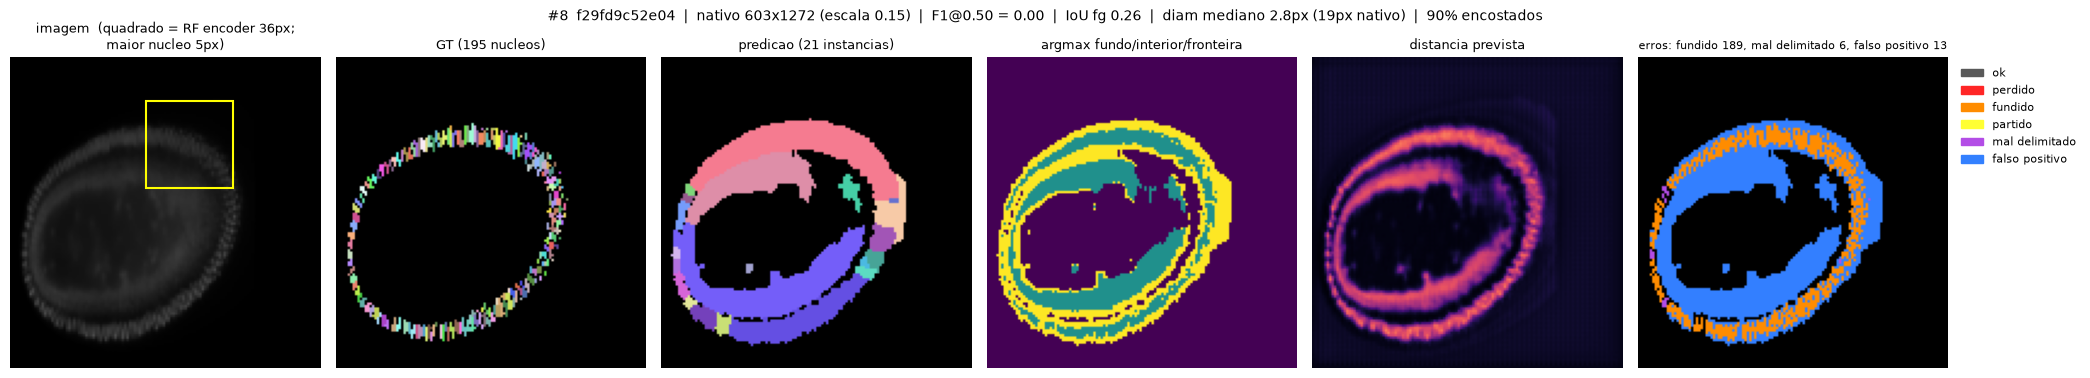

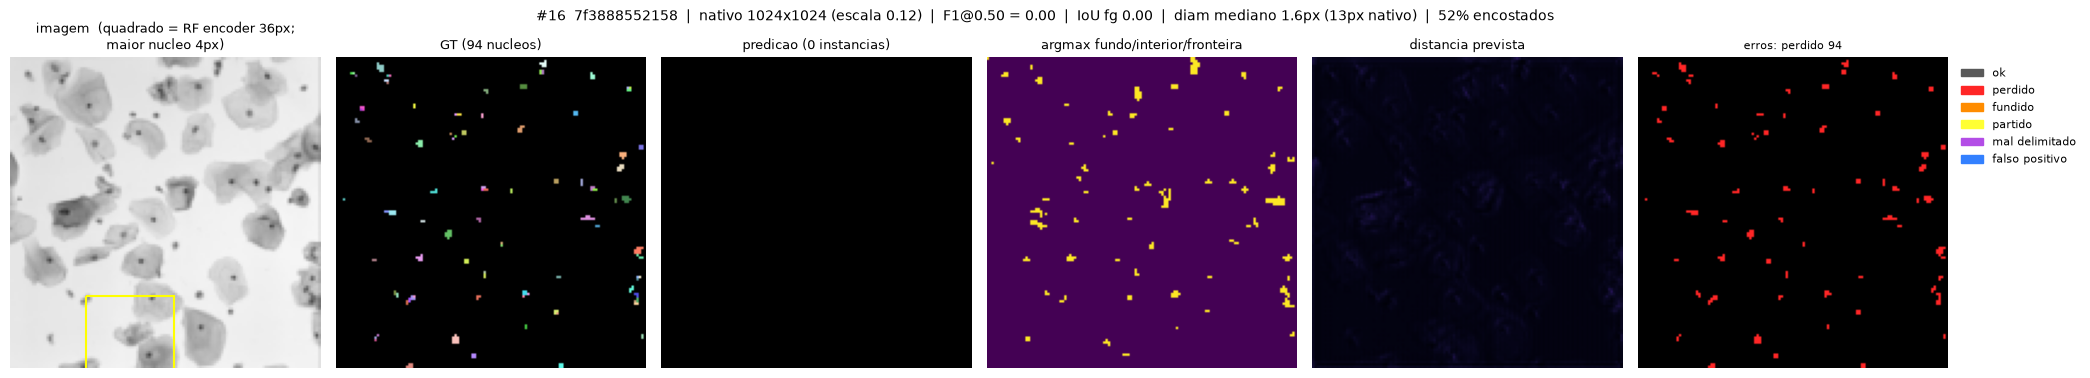

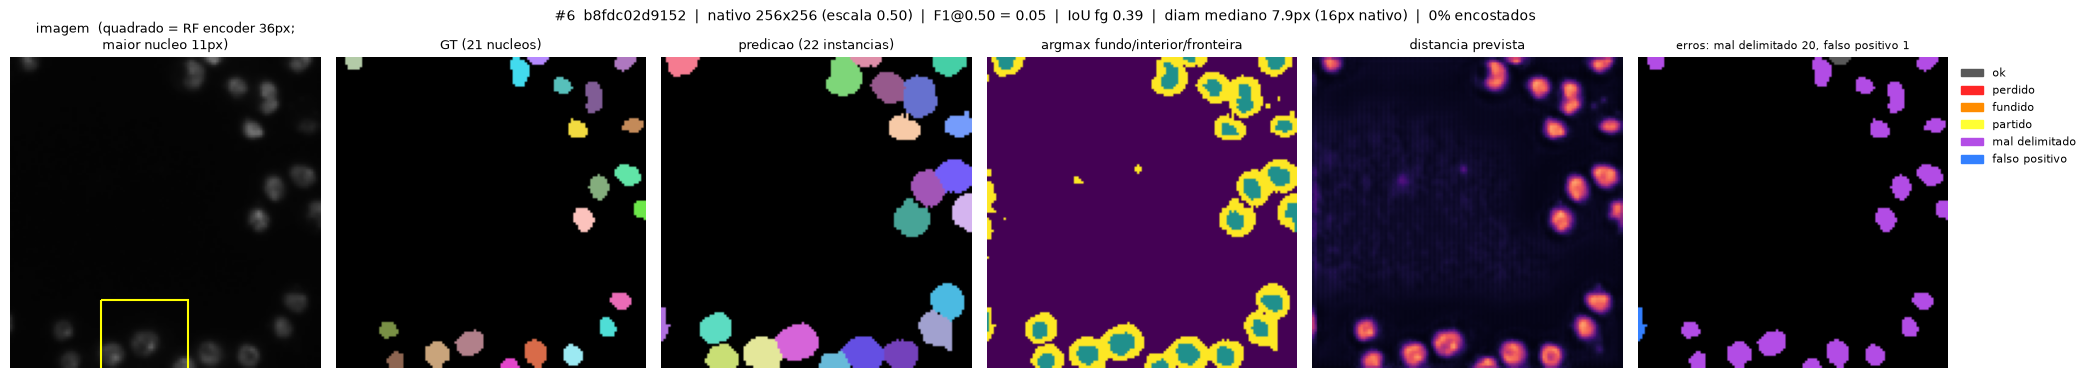

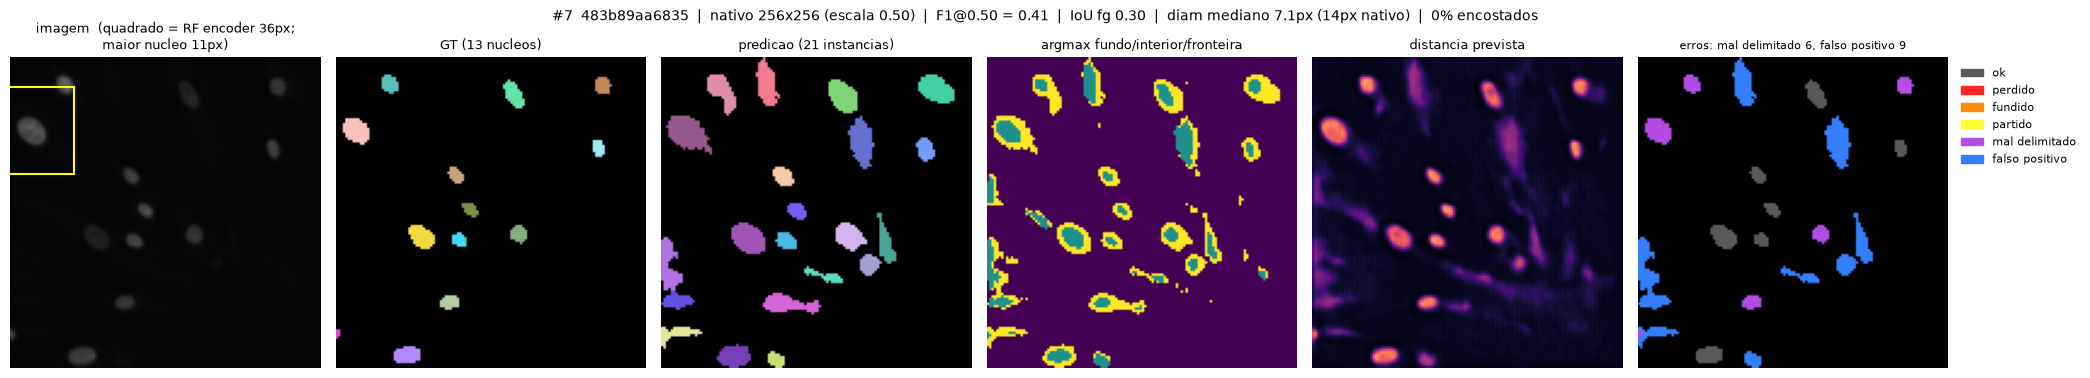

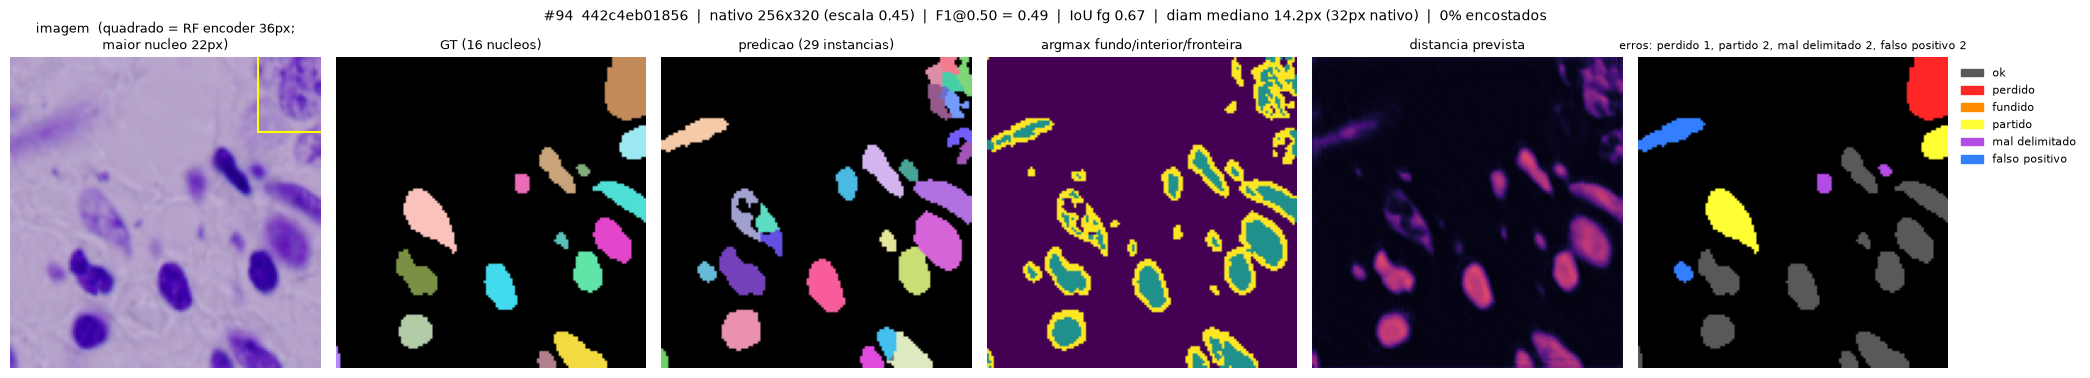

In [11]:
# ============================================================
# FIGURAS DA GALERIA
# ============================================================

def colorize(label_map, seed=0):
    n = int(label_map.max())
    rng = np.random.default_rng(seed)
    lut = rng.uniform(0.25, 1.0, size=(n + 1, 3)).astype(np.float32)
    lut[0] = 0.0
    return lut[label_map]


def error_panel(pred, gt, categories, fp_flags):
    rgb = np.zeros(gt.shape + (3,), dtype=np.float32)
    for g, cat in enumerate(categories, start=1):
        rgb[gt == g] = ERROR_COLORS[cat]
    for p, flag in enumerate(fp_flags, start=1):
        if flag:
            rgb[(pred == p) & (gt == 0)] = ERROR_COLORS["falso positivo"]
    return rgb


def largest_object(gt):
    areas = np.bincount(gt.ravel()); areas[0] = 0
    k = int(areas.argmax())
    ys, xs = np.nonzero(gt == k)
    return k, (ys.mean(), xs.mean()), 2 * np.sqrt(areas[k] / np.pi)


def gallery_figure(rec, rf=RF_ENCODER, title_extra=""):
    image = np.transpose(rec["image"], (1, 2, 0))
    k, (cy, cx), diam = largest_object(rec["gt"])

    fig, ax = plt.subplots(1, 6, figsize=(21, 3.9))
    ax[0].imshow(image)
    ax[0].add_patch(patches.Rectangle((cx - rf / 2, cy - rf / 2), rf, rf, fill=False, edgecolor="yellow", linewidth=1.5))
    ax[0].set_title(f"imagem  (quadrado = RF encoder {rf}px;\nmaior nucleo {diam:.0f}px)", fontsize=9)
    ax[1].imshow(colorize(rec["gt"]));   ax[1].set_title(f"GT ({rec['n_gt']} nucleos)", fontsize=9)
    ax[2].imshow(colorize(rec["pred"], seed=1)); ax[2].set_title(f"predicao ({rec['n_pred']} instancias)", fontsize=9)
    ax[3].imshow(rec["sem_prob"].argmax(axis=0), vmin=0, vmax=2, cmap="viridis"); ax[3].set_title("argmax fundo/interior/fronteira", fontsize=9)
    ax[4].imshow(rec["dist"], vmin=0, vmax=1, cmap="magma"); ax[4].set_title("distancia prevista", fontsize=9)
    ax[5].imshow(error_panel(rec["pred"], rec["gt"], rec["categories"], rec["fp_flags"]))
    ax[5].set_title("erros: " + ", ".join(f"{k} {v}" for k, v in rec["errors"].items() if v), fontsize=8)
    for a in ax:
        a.axis("off")
    ax[5].legend(handles=[patches.Patch(color=c, label=n) for n, c in ERROR_COLORS.items()],
                 loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
    fig.suptitle(f"#{rec['pos']}  {rec['sample_id']}  |  nativo {rec['native'][0]}x{rec['native'][1]} (escala {rec['scale']:.2f})  |  "
                 f"F1@0.50 = {rec['f1']:.2f}  |  IoU fg {rec['sem_iou']:.2f}  |  diam mediano {rec['diam_median']:.1f}px "
                 f"({rec['diam_median'] / rec['scale']:.0f}px nativo)  |  {100 * rec['touching']:.0f}% encostados{title_extra}",
                 fontsize=10)
    plt.tight_layout(); plt.show()


for rec in gallery:
    gallery_figure(rec)

## Diagnósticos

A régua do enunciado — *"o objeto tem 180 px e o campo receptivo é 140 px"* —
**não** se aplica a esta rede na resolução de treino: o encoder vê 36 px, a saída
60–64 px, e **nenhum** núcleo a 128×128 passa de 42 px (0 % acima do RF do
encoder). O quadrado amarelo nas figuras cobre o maior núcleo de cada imagem
com folga. O que aparece na galeria é o problema **inverso**: o *resize* para
128×128 destrói a informação antes de ela chegar à rede.

**#8 — 189 núcleos fundidos em 21 instâncias (F1 = 0).** Corte histológico de
603×1272 reduzido a 128×128: escala 0,15 e, pior, **anisotrópica** (÷4,7 na
vertical, ÷9,9 na horizontal). Os 195 núcleos, de 19 px nativos, viram 2,8 px;
98 % ficam abaixo de 4 px e 90 % encostam no vizinho. A 128 a fronteira entre
dois núcleos encostados tem menos de 1 px: a rede prevê o anel inteiro como uma
faixa contínua de interior + fronteira e o watershed o inunda em meia dúzia de
bacias. O RF de 36 px cobre ~13 núcleos de uma vez — o problema não é ver
pouco, é a informação não existir mais na entrada. A rede ainda "fecha" o anel
com um interior falso no centro (falsos positivos em azul): nunca viu uma
estrutura oca. → **resolução** (a correção da seção 4).

**#16 — 94 núcleos perdidos, 0 instâncias.** Campo claro 1024×1024 (escala
0,12): núcleos de 13 px nativos viram **1,6 px**; 100 % abaixo de 4 px. Com
fronteira de 1 px, um núcleo de 1,6 px não tem interior nem no GT — o teto do
decodificador para esta imagem é zero. A rede ainda marca pixels isolados como
fronteira (amarelo no `argmax`), mas sem interior não há marcador e o watershed
não nasce. Soma-se a modalidade: fundo claro (brilho médio 0,84) com células
cinza é raro no treino. → **resolução** (+ modalidade).

**#6 — contagem certa (22 vs 21), F1 = 0,05: 20 núcleos mal delimitados.**
Fluorescência muito escura (brilho médio 0,03), núcleos isolados de 8 px. A rede
encontra todos, mas os **infla**: prevê uma casca de fronteira de 3–4 px em
torno de cada núcleo (o alvo tem 1 px) e o watershed inunda tudo que não é
fundo, então cada instância sai ~2× maior que o GT e o IoU cai abaixo de 0,50.
É um erro de delimitação, não de detecção — mAP zero com contagem perfeita.
Causa provável: o halo dos núcleos fracos somado à perda balanceada, que paga
caro por fronteira perdida e barato por fronteira a mais. Correção sugerida
(não implementada aqui): inundar só onde `distância > τ` ou
`P(interior) + P(fronteira) > 0,5`, em vez de `argmax ≠ fundo`. → **delimitação**.

**#7 — 9 falsos positivos e 6 mal delimitados.** Mesma modalidade escura
(brilho 0,03), com filamentos de citoplasma fracos ao fundo. Os 13 núcleos são
detectados, mas os filamentos alongados — cristas no mapa de distância — passam
do limiar e viram instâncias. `SegmentationTransform` **não normaliza
intensidade por imagem**: um fundo a 3 % de brilho com estruturas a 6 % é, para a
rede, indistinguível de um núcleo fraco numa imagem normal. → **contraste /
normalização**.

**#94 — 2 partidos, 1 perdido, 2 falsos positivos em núcleos grandes de
histologia.** Núcleos de 14 px (32 px nativos; o maior tem 22 px, 50 nativos),
roxos sobre citoplasma roxo-claro. A fronteira prevista aparece **dentro** do
núcleo grande (a cromatina heterogênea gera bordas internas), o interior vira
ilhas e o watershed o parte; o núcleo cortado pela borda da imagem fica sem
marcador. O campo receptivo ainda não é a explicação — 36 px > 22 px — mas
aqui vale a conta do enunciado, para a Parte 6: em resolução nativa o mesmo
núcleo tem 50 px > 36 px do encoder; a 2× a rede não veria as duas bordas de
uma vez. → **textura interna / modalidade minoritária** (duas das cinco falhas
são imagens de fundo claro).

**Diagnóstico dominante na validação inteira:** 1584 dos 6051 núcleos (26 %)
são *fundidos* e 547 (9 %) *perdidos* — os dois sintomas de resolução. É a
mudança que a seção 4 implementa.

## 4. Correção: subir a resolução de entrada para 256×256

**Diagnóstico escolhido.** O campo receptivo **não** é o gargalo a 128×128:
nenhum núcleo ultrapassa os 36 px do encoder (nem os 60–64 da saída). O gargalo
é o oposto — o *resize* para 128×128 encolhe o núcleo mediano para ~6 px e um
terço deles para menos de 5 px; entre dois núcleos encostados sobra menos de um
pixel de fronteira, e a classe *fronteira* (1 px) e o marcador de watershed
(≥ 2 px de interior) deixam de existir. Os erros dominantes da galeria e da
validação inteira — núcleos **fundidos** (26 %) e **perdidos** (9 %) — são o
sintoma esperado desse diagnóstico.

**A mudança que ele sugere.** Não jogar a resolução fora: entrada a 256×256
(diâmetro mediano ~12 px, fronteira de 2 px). O campo receptivo continua
sobrando (36 px do encoder cobrem 97 % dos núcleos a 256; os 60–64 da saída,
100 %), então a rede não precisa mudar — só a resolução. A espessura da fronteira e o tamanho mínimo de marcador
dobram junto (`DECODE[256]`), mantendo o mesmo teto de decodificador (~88–89 %
dos núcleos do GT com marcador) — a variável isolada é a resolução.

**Protocolo (antes/depois com controle).**

| configuração | o que é |
|---|---|
| **antes** | checkpoint da Parte 4, avaliado a 128 |
| **só inferência @256** | o mesmo checkpoint, entrada a 256 sem retreinar — mede se a rede generaliza à escala (assunto da Parte 6) |
| **controle: +`FT_EPOCHS` @128** | mais `FT_EPOCHS` épocas a 128 — mesmo orçamento extra de treino, sem mudar a resolução |
| **depois: +`FT_EPOCHS` @256** | as mesmas `FT_EPOCHS` épocas, a 256, partindo do checkpoint da Parte 4 |

Se "depois" superar o "controle", o ganho é da resolução, não das épocas
extras. O GT também é reamostrado a 256 (mais núcleos sobrevivem ao
`min_pixels`), por isso a tabela reporta `n_gt` por configuração.

In [12]:
# ============================================================
# FINE-TUNING  (controle @128  e  correcao @256)  --  ou carga dos checkpoints
# ============================================================

init_state = copy.deepcopy(model.state_dict())

model_ft128, hist_ft128 = load_or_train(CHECKPOINT_FT128, TRAIN_SIZE, FT_EPOCHS, init_state=init_state, lr=FT_LR,
                                        tag=f"controle +{FT_EPOCHS} ep @{TRAIN_SIZE}")
model_ft256, hist_ft256 = load_or_train(CHECKPOINT_FT256, CORRECTION_SIZE, FT_EPOCHS, init_state=init_state, lr=FT_LR,
                                        tag=f"correcao +{FT_EPOCHS} ep @{CORRECTION_SIZE}")

[controle +3 ep @128] checkpoint carregado: results\5_trilha_a_unet_ft128.pt  (config: {"backbone": "unet", "loss": {"kind": "focal", "gamma": 2.0, "balanced": true}, "boundary_width": 1, "image_size": [128, 128], "epochs": 3, "lr": 0.0005, "from": "results\\4_trilha_a_unet.pt", "min_marker_size": 2, "split_seed": 67})
[correcao +3 ep @256] checkpoint carregado: results\5_trilha_a_unet_ft256.pt  (config: {"backbone": "unet", "loss": {"kind": "focal", "gamma": 2.0, "balanced": true}, "boundary_width": 2, "image_size": [256, 256], "epochs": 3, "lr": 0.0005, "from": "results\\4_trilha_a_unet.pt", "min_marker_size": 4, "split_seed": 67})


In [13]:
# ============================================================
# AVALIACAO DAS QUATRO CONFIGURACOES
# ============================================================

gallery_pos = {r["pos"] for r in gallery}

configs = {
    "antes (Parte 4 @128)":                    (model,       TRAIN_SIZE,      records, summary_before),
    f"so inferencia @{CORRECTION_SIZE}":       (model,       CORRECTION_SIZE, None, None),
    f"controle: +{FT_EPOCHS} ep @{TRAIN_SIZE}": (model_ft128, TRAIN_SIZE,      None, None),
    f"depois: +{FT_EPOCHS} ep @{CORRECTION_SIZE}": (model_ft256, CORRECTION_SIZE, None, None),
}

eval_results = {}
for name, (m, size, recs, summ) in configs.items():
    if recs is None:
        t0 = time.time()
        recs, summ = evaluate_split(m, size, DECODE[size]["min_marker_size"], keep_dense=gallery_pos)
        print(f"{name}: avaliado em {time.time() - t0:.0f}s")
    eval_results[name] = (recs, summ)

correction_table = pd.DataFrame({name: summ for name, (_, summ) in eval_results.items()})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
correction_table

so inferencia @256: avaliado em 25s
controle: +3 ep @128: avaliado em 10s
depois: +3 ep @256: avaliado em 25s


,antes (Parte 4 @128),so inferencia @256,controle: +3 ep @128,depois: +3 ep @256
resolucao,128.0000,256.0000,128.0000,256.0000
n_gt,6051.0000,6127.0000,6051.0000,6127.0000
IoU (semantico),0.6097,0.6127,0.6773,0.6993
mAP@[.50:.95],0.1710,0.1883,0.2158,0.2752
AP@0.50,0.4895,0.4675,0.5153,0.5374
AP@0.75,0.0580,0.1340,0.1342,0.2653
TP@0.50,3462.0000,3356.0000,3591.0000,3719.0000
FP@0.50,1080.0000,1835.0000,920.0000,852.0000
FN@0.50,2589.0000,2771.0000,2460.0000,2408.0000
erro medio de contagem,12.4254,13.2687,12.2090,12.6716


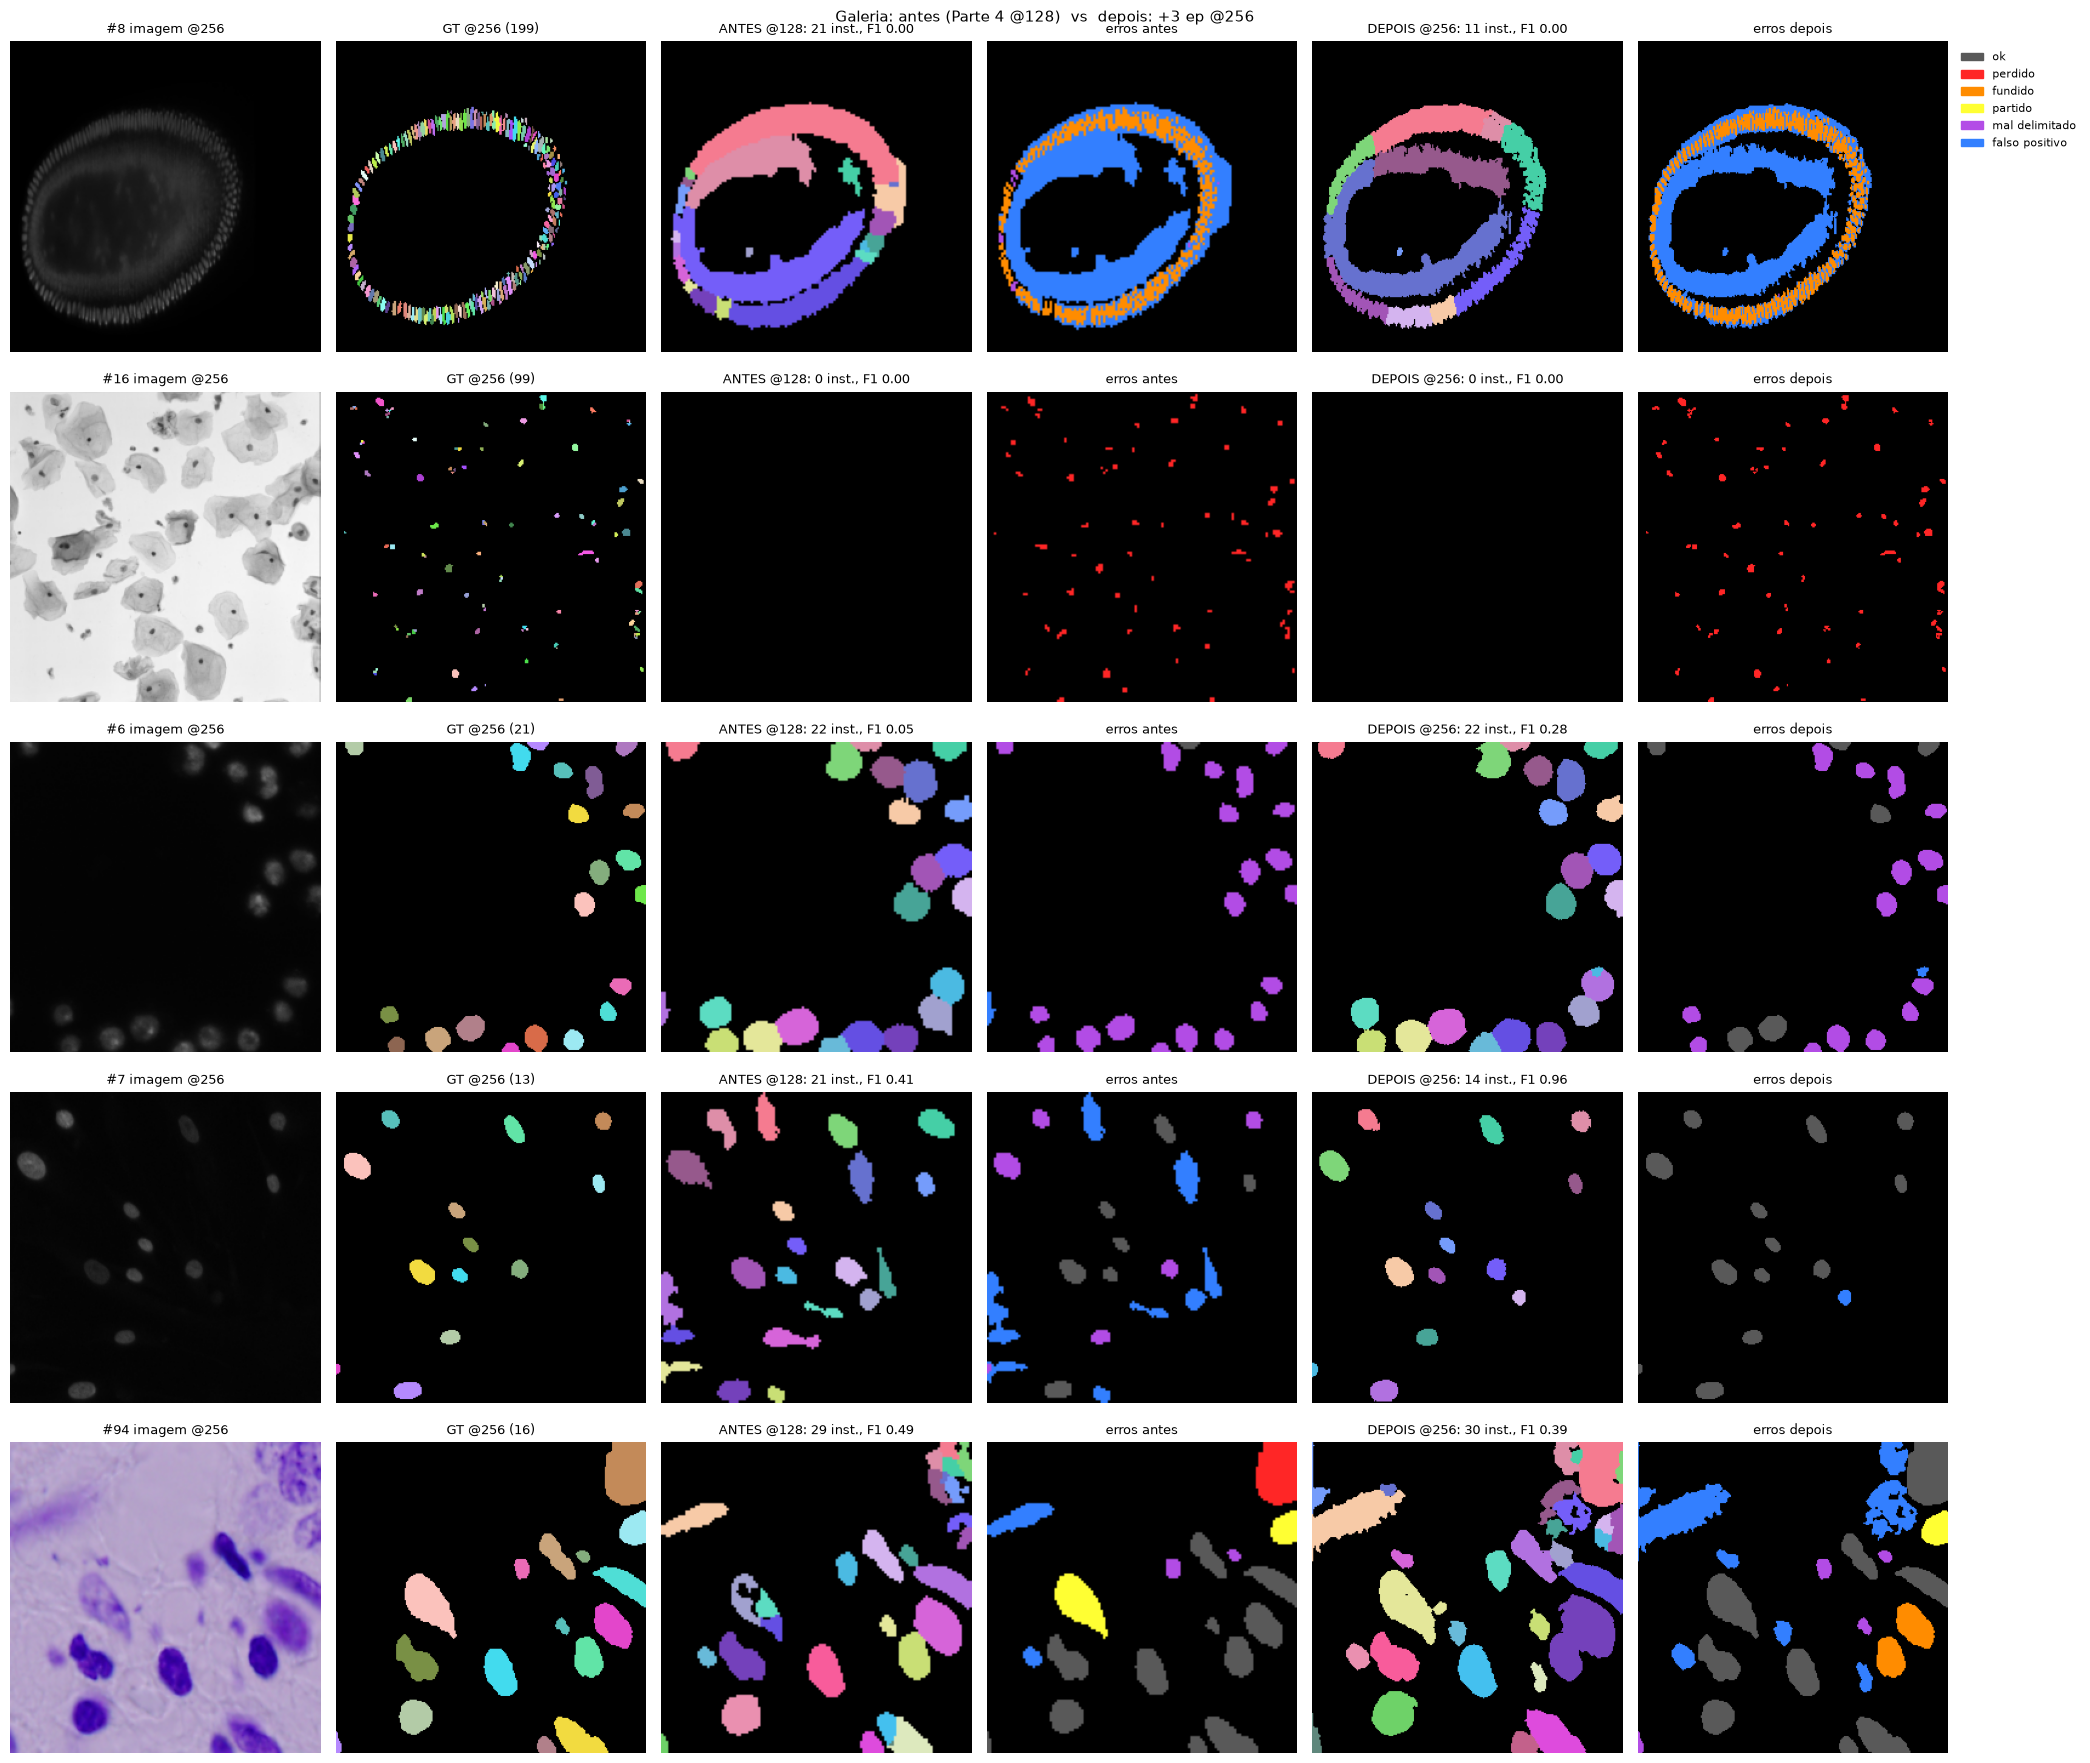

,amostra,F1 antes,F1 depois,n_gt antes,n_gt depois,fundidos antes,fundidos depois,perdidos antes,perdidos depois,FP antes,FP depois
pos,,,,,,,,,,,
8,f29fd9c52e04,0.0000,0.0000,195,199,189,198,0,0,13,11
16,7f3888552158,0.0000,0.0000,94,99,0,0,94,99,0,0
6,b8fdc02d9152,0.0470,0.2790,21,21,0,0,0,0,1,1
7,483b89aa6835,0.4120,0.9630,13,13,0,0,0,0,9,1
94,442c4eb01856,0.4890,0.3910,16,16,0,2,1,0,2,12


In [14]:
# ============================================================
# ANTES / DEPOIS  --  nas cinco imagens da galeria
# ============================================================

before_name = list(configs)[0]
after_name  = list(configs)[-1]
recs_before = eval_results[before_name][0]
recs_after  = eval_results[after_name][0]

rows = []
fig, ax = plt.subplots(N_GALLERY, 6, figsize=(21, 3.6 * N_GALLERY))
for r, rec in enumerate(gallery):
    b = recs_before[rec["pos"]]
    a = recs_after[rec["pos"]]
    rows.append({"pos": rec["pos"], "amostra": rec["sample_id"],
                 "F1 antes": round(b["f1"], 3), "F1 depois": round(a["f1"], 3),
                 "n_gt antes": b["n_gt"], "n_gt depois": a["n_gt"],
                 "fundidos antes": b["errors"]["fundido"], "fundidos depois": a["errors"]["fundido"],
                 "perdidos antes": b["errors"]["perdido"], "perdidos depois": a["errors"]["perdido"],
                 "FP antes": b["errors"]["falso positivo"], "FP depois": a["errors"]["falso positivo"]})

    ax[r, 0].imshow(np.transpose(a["image"], (1, 2, 0)));     ax[r, 0].set_title(f"#{rec['pos']} imagem @{CORRECTION_SIZE}", fontsize=9)
    ax[r, 1].imshow(colorize(a["gt"]));                        ax[r, 1].set_title(f"GT @{CORRECTION_SIZE} ({a['n_gt']})", fontsize=9)
    ax[r, 2].imshow(colorize(b["pred"], seed=1));              ax[r, 2].set_title(f"ANTES @{TRAIN_SIZE}: {b['n_pred']} inst., F1 {b['f1']:.2f}", fontsize=9)
    ax[r, 3].imshow(error_panel(b["pred"], b["gt"], b["categories"], b["fp_flags"])); ax[r, 3].set_title("erros antes", fontsize=9)
    ax[r, 4].imshow(colorize(a["pred"], seed=1));              ax[r, 4].set_title(f"DEPOIS @{CORRECTION_SIZE}: {a['n_pred']} inst., F1 {a['f1']:.2f}", fontsize=9)
    ax[r, 5].imshow(error_panel(a["pred"], a["gt"], a["categories"], a["fp_flags"])); ax[r, 5].set_title("erros depois", fontsize=9)
    for a_ in ax[r]:
        a_.axis("off")
ax[0, 5].legend(handles=[patches.Patch(color=c, label=n) for n, c in ERROR_COLORS.items()],
                loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
plt.suptitle(f"Galeria: {before_name}  vs  {after_name}", fontsize=11)
plt.tight_layout(); plt.show()

pd.DataFrame(rows).set_index("pos")

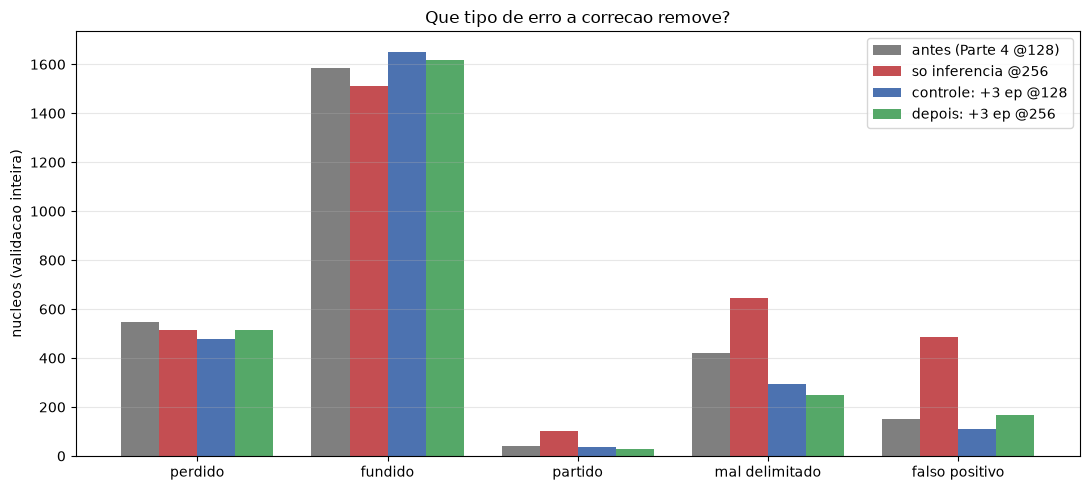

In [15]:
# ============================================================
# ERROS POR CATEGORIA  --  as quatro configuracoes, validacao inteira
# ============================================================

cats = ["perdido", "fundido", "partido", "mal delimitado", "falso positivo"]
x = np.arange(len(cats)); w = 0.2
colors = ["#7f7f7f", "#c44e52", "#4c72b0", "#55a868"]

plt.figure(figsize=(11, 5))
for k, (name, (_, summ)) in enumerate(eval_results.items()):
    plt.bar(x + (k - 1.5) * w, [summ[c] for c in cats], width=w, label=name, color=colors[k])
plt.xticks(x, cats); plt.ylabel("nucleos (validacao inteira)")
plt.title("Que tipo de erro a correcao remove?"); plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
# ============================================================
# SALVA OS NUMEROS DA PARTE 5
# ============================================================

payload = {
    "campo_receptivo": {
        "unet_encoder_px": int(RF_ENCODER), "unet_saida_px": int(RF_OUTPUT),
        "unet_camadas": unet_rows, "deeplab_com_sem_atrous": rf_table,
        "conferencia_empirica": {k: list(v) for k, v in checks.items()},
    },
    "tamanhos_objetos": {
        "n_mascaras": int(len(sizes)),
        "estatisticas_px": size_stats.round(2).to_dict(orient="index"),
        "frac_maior_que_rf_encoder": {"nativo": float((sizes.d_nativo > RF_ENCODER).mean()),
                                      "@128": float((sizes.d_128 > RF_ENCODER).mean()),
                                      "@256": float((sizes.d_256 > RF_ENCODER).mean())},
        "frac_menor_que_5px": {"nativo": float((sizes.d_nativo < 5).mean()),
                               "@128": float((sizes.d_128 < 5).mean()), "@256": float((sizes.d_256 < 5).mean())},
    },
    "galeria": evidence.reset_index().to_dict(orient="records"),
    "correcao": {
        "config": {"resolucao": CORRECTION_SIZE, "ft_epochs": FT_EPOCHS, "ft_lr": FT_LR, "decode": DECODE},
        "validacao": {name: summ for name, (_, summ) in eval_results.items()},
        "galeria_antes_depois": rows,
    },
}

def _default(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, np.ndarray): return o.tolist()
    return str(o)

with open(os.path.join(RESULTS_DIR, "5_failure_gallery.json"), "w") as fh:
    json.dump(payload, fh, indent=2, default=_default)

print(json.dumps(payload["correcao"]["validacao"], indent=2, default=_default))

{
  "antes (Parte 4 @128)": {
    "resolucao": 128,
    "n_gt": 6051,
    "IoU (semantico)": 0.6096532620860852,
    "mAP@[.50:.95]": 0.17099104897301703,
    "AP@0.50": 0.4894836833911511,
    "AP@0.75": 0.05795848546785271,
    "TP@0.50": 3462,
    "FP@0.50": 1080,
    "FN@0.50": 2589,
    "erro medio de contagem": 12.425373134328359,
    "perdido": 547,
    "fundido": 1584,
    "partido": 39,
    "mal delimitado": 419,
    "falso positivo": 150
  },
  "so inferencia @256": {
    "resolucao": 256,
    "n_gt": 6127,
    "IoU (semantico)": 0.6127211774493861,
    "mAP@[.50:.95]": 0.18828923014100568,
    "AP@0.50": 0.46748071537155134,
    "AP@0.75": 0.13395693412466364,
    "TP@0.50": 3356,
    "FP@0.50": 1835,
    "FN@0.50": 2771,
    "erro medio de contagem": 13.26865671641791,
    "perdido": 514,
    "fundido": 1510,
    "partido": 100,
    "mal delimitado": 647,
    "falso positivo": 484
  },
  "controle: +3 ep @128": {
    "resolucao": 128,
    "n_gt": 6051,
    "IoU (semantico)"

* **Campo receptivo.** Encoder da U-Net: **36 px** (fórmula dos slides = autograd);
  saída, após o decoder: 64 px pela fórmula, 60 medidos (o alinhamento do pixel com
  as grades de pooling decide). DeepLabV3, na **mesma** resolução de saída (stride 2):
  encoder 30 px com *atrous* vs. 22 px sem — a dilatação compra campo receptivo sem
  pagar em resolução; com a ASPP, 104 vs. 96 px. A U-Net precisa de três pools
  (stride 8) para chegar a 36.
* **Campo receptivo × tamanho dos objetos.** Nativo: núcleo mediano 20 px, p99 60 px;
  9 % ultrapassam os 36 px do encoder. A 128×128 (treino): mediano 6 px, máximo 42 px —
  **0 %** ultrapassam o encoder e 31 % ficam abaixo de 5 px. O diagnóstico
  "objeto maior que o campo receptivo" **não** descreve este modelo; o inverso
  ("objeto menor que a resolução") descreve. Só a 2× (Parte 6) o RF volta a importar:
  3 % dos núcleos passam de 36 px.
* **Galeria.** Cinco falhas de tipos distintos — anel de 195 núcleos de 2,8 px
  fundidos em 21 instâncias (#8), 94 núcleos de 1,6 px perdidos com 0 instâncias
  (#16), contagem perfeita com mAP zero por inflação das máscaras (#6), 9 falsos
  positivos em filamentos de uma imagem a 3 % de brilho (#7) e núcleos grandes de
  histologia partidos pela textura interna (#94). Na validação inteira: 1584
  fundidos (26 %), 547 perdidos, 419 mal delimitados, 150 falsos positivos.
* **Correção (resolução 128 → 256), com controle.** Só inferir a 256 já sobe o mAP
  (0,171 → 0,188, AP@0,75 0,058 → 0,134) mas fragmenta (FP 150 → 484). O controle
  (+3 épocas a 128) vai a 0,216 — o modelo da Parte 4 estava subtreinado, e sem
  controle esse ganho seria atribuído à resolução. **Depois (+3 épocas a 256):
  mAP 0,275, AP@0,75 0,265** — +0,06 mAP e o dobro de AP@0,75 sobre o controle,
  com mal delimitados 294 → 247. O ganho é real e vem da resolução.
* **O que a correção não fez — e o que isso revela.** Os *fundidos* não caíram
  (1652 no controle, 1619 depois) e #8/#16 continuam com F1 = 0. Essas imagens
  têm escala nativa 0,12–0,15: a 256 os núcleos ainda têm 3–6 px, abaixo do que a
  fronteira de 2 px separa. O diagnóstico "resolução" estava certo, mas a dose
  estava errada — o fator de resize dessas imagens é 7–10×, não 2×. A resolução
  fixa (256×256 para tudo) é o erro de projeto: o certo é reamostrar por
  **tamanho de núcleo**, não por tamanho de imagem. E #94 piorou (0,49 → 0,39):
  a 256 o maior núcleo tem 44 px > 36 px do encoder e a textura interna gera mais
  fragmentos — a partir daí o campo receptivo passa a ser o limite, como o
  enunciado previa. É a transição que a Parte 6 mede.
* **Limitação declarada:** 3 épocas de fine-tuning (orçamento de CPU); a curva de
  perda ainda cai. Os números comparam tendências sob o mesmo orçamento, não o
  teto de cada configuração.